# ANADI – Trabalho Prático 2
## 4.1 Análise Exploratória de Dados (EDA)
**Dataset:** PTD_level_dataset.xlsx  
**Objetivo:** Analisar o impacto da eficiência energética na iluminação pública sobre a reserva de potência dos Postos de Transformação de Distribuição (PTD) e avaliar a viabilidade de instalação de carregadores de veículos elétricos.

---
## 1. Carregamento do Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import os
from pathlib import Path

# Garante que o diretório de trabalho é o da pasta do notebook (funciona em qualquer PC)
try:
    os.chdir(Path(__vsc_ipynb_file__).parent)
except NameError:
    pass  # Jupyter clássico: lançar a partir da pasta do projeto

sns.set_theme(style='whitegrid')
%matplotlib inline

df = pd.read_excel('data/PTD_level_dataset.xlsx')
print('Dimensão do dataset:', df.shape)
print(f'Registos: {df.shape[0]:,} | Variáveis: {df.shape[1]}')

Dimensão do dataset: (72027, 32)
Registos: 72,027 | Variáveis: 32


In [2]:
# Primeiros registos
df.head()

,Distrito,Concelho,CodDistritoConcelho,Código de Instalação,Coordenadas Geográficas,Potência instalada [kVA],Tipo Construtivo,Cap_PTD_kVA,Pot_Contratada_kVA,N_Clientes,...,IP_Inef_per_PTD,Ganho_LED_PTD,D_PTD_LED,Cap_per_Cliente,PContratada_per_Cliente,Geracao_per_Cliente,Clientes_Produtores_Ratio,Nível de Utilização [%],Util_Decimal,PFolga_PTD
0,Porto,Marco de Canaveses,1307,1307D2012500,"41.1849010463209, -8.14785254356171",400,Cabine pré-fabricada,400,105269.0,131,...,2.671833,1.736691,65.816691,3.053435,803.580153,NaN,0.152672,60%-79%,0.79,77.28
1,Porto,Marco de Canaveses,1307,1307D2012900,"41.0869934226954, -8.24673374651495",250,Cabine baixa integrada em edifício,250,77520.0,115,...,2.671833,1.736691,36.836691,2.173913,674.086957,NaN,0.173913,60%-79%,0.79,48.30
2,Porto,Marco de Canaveses,1307,1307D2013100,"41.1129221154249, -8.21276525945275",250,Cabine alta,250,110419.0,176,...,2.671833,1.736691,36.836691,1.420455,627.380682,NaN,0.113636,60%-79%,0.79,48.30
3,Porto,Marco de Canaveses,1307,1307D2013800,"41.1329530486552, -8.13563404382479",50,Aéreo - AS,50,23807.0,36,...,2.671833,1.736691,-11.463309,1.388889,661.305556,NaN,0.555556,+100%,1.00,0.00
4,Porto,Marco de Canaveses,1307,1307D2015100,"41.1228444565974, -8.11290068900831",250,Aéreo - AI,250,60851.0,94,...,2.671833,1.736691,174.836691,2.659574,647.351064,NaN,0.212766,0%-19%,0.19,186.30


In [3]:
# Informação geral: tipos de dados e contagem de não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72027 entries, 0 to 72026
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Distrito                   72027 non-null  object 
 1   Concelho                   72027 non-null  object 
 2   CodDistritoConcelho        72027 non-null  int64  
 3   Código de Instalação       72027 non-null  object 
 4   Coordenadas Geográficas    72027 non-null  object 
 5   Potência instalada [kVA]   72027 non-null  int64  
 6   Tipo Construtivo           72027 non-null  object 
 7   Cap_PTD_kVA                72027 non-null  int64  
 8   Pot_Contratada_kVA         50847 non-null  float64
 9   N_Clientes                 72027 non-null  int64  
 10  Pot_Geracao_kW             1836 non-null   float64
 11  N_Clientes_Produtores      72027 non-null  int64  
 12  P_IP_Total                 72027 non-null  float64
 13  P_IP_Inef                  72027 non-null  flo

In [4]:
# Sumário estatístico das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CodDistritoConcelho,72027.0,989.432671,4.939913e+02,101.000000,603.000000,1106.000000,1317.000000,1824.000000
Potência instalada [kVA],72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Cap_PTD_kVA,72027.0,302.798825,2.944445e+02,0.000000,100.000000,250.000000,400.000000,8000.000000
Pot_Contratada_kVA,50847.0,80941.484060,6.714603e+04,5456.000000,34035.500000,60886.000000,106720.000000,804687.000000
N_Clientes,72027.0,94.698002,1.100551e+02,20.000000,20.000000,54.000000,124.000000,1438.000000
Pot_Geracao_kW,1836.0,6216.724401,2.876378e+03,1622.000000,4271.750000,5574.500000,7393.500000,22032.000000
N_Clientes_Produtores,72027.0,20.203479,2.017686e+00,20.000000,20.000000,20.000000,20.000000,106.000000
P_IP_Total,72027.0,1381.490215,1.723711e+03,23.218600,382.569000,842.179701,1766.391301,9065.655300
P_IP_Inef,72027.0,463.290614,7.080096e+02,0.000000,28.985000,137.720000,625.790000,3494.920000
Rate_Ineficiencia,72027.0,0.280694,2.403671e-01,0.000000,0.064209,0.229231,0.447381,0.983568


---
## 2. Exploração Visual dos Dados

### 2.1 Valores Omissos

                         Valores Omissos  Percentagem (%)
Pot_Geracao_kW                     70191            97.45
Geracao_per_Cliente                70191            97.45
PContratada_per_Cliente            21180            29.41
Pot_Contratada_kVA                 21180            29.41
D_PTD_LED                           3064             4.25
D_PTD                               3064             4.25
Util_Decimal                        3064             4.25
PFolga_PTD                          3064             4.25


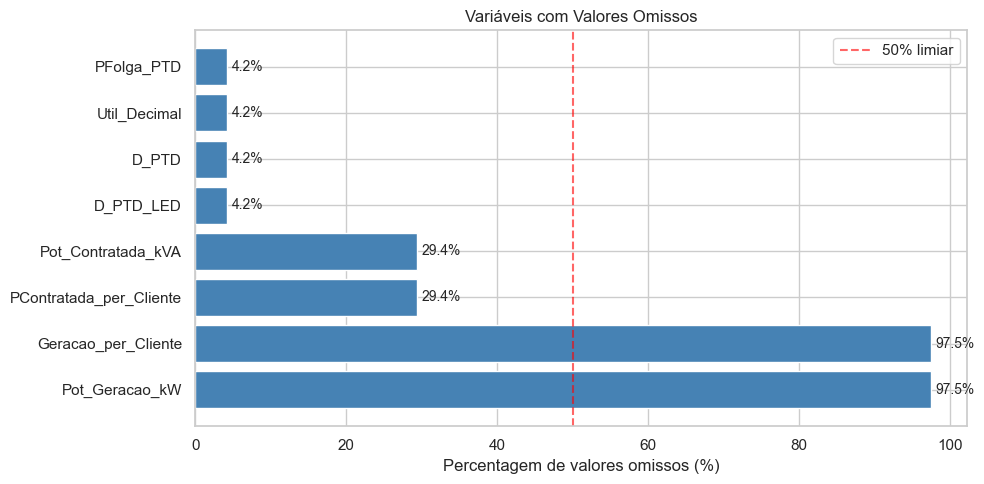

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores Omissos': missing, 'Percentagem (%)': missing_pct})
missing_df = missing_df[missing_df['Valores Omissos'] > 0].sort_values('Percentagem (%)', ascending=False)

print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Percentagem (%)'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_xlabel('Percentagem de valores omissos (%)')
ax.set_title('Variáveis com Valores Omissos')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.6, label='50% limiar')
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Distribuição da Variável Categórica: Tipo Construtivo

C:\Users\zeraf\AppData\Local\Temp\ipykernel_10560\4022834290.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tipo_counts.values, y=tipo_counts.index, ax=axes[0], palette='Blues_r')


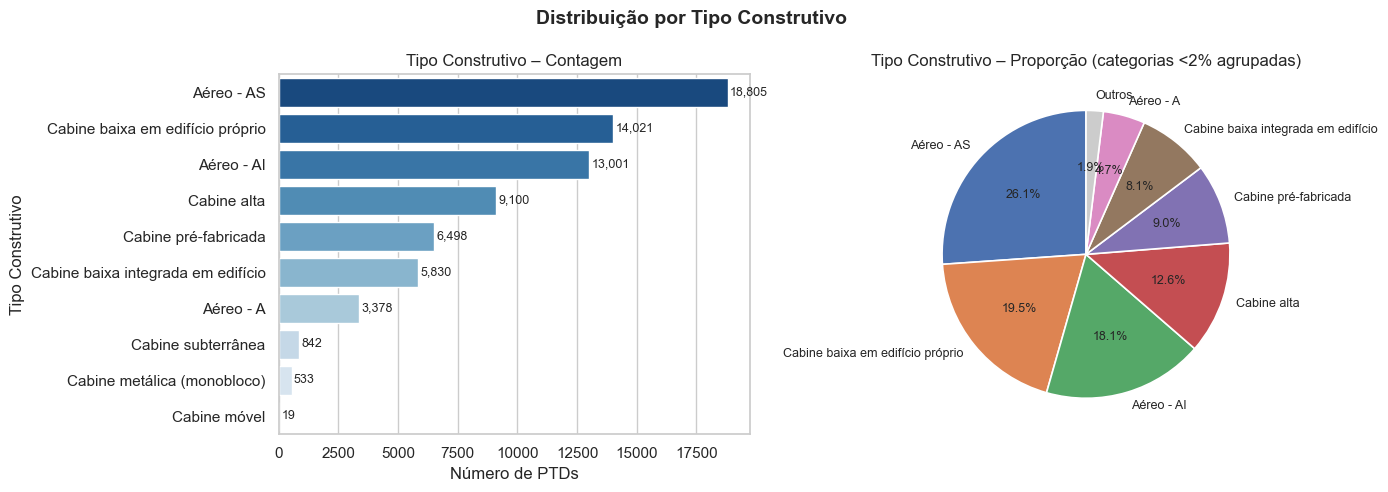

Categorias agrupadas em "Outros" (< 2% = < 1441 PTDs):
  - Cabine subterrânea: 842 PTDs (1.17%)
  - Cabine metálica (monobloco): 533 PTDs (0.74%)
  - Cabine móvel: 19 PTDs (0.03%)


In [6]:
tipo_counts = df['Tipo Construtivo'].value_counts()

# Agrupar categorias raras (< 2%) em "Outros"
threshold = 0.02 * tipo_counts.sum()
outros_sum = tipo_counts[tipo_counts < threshold].sum()
tipo_grouped = tipo_counts[tipo_counts >= threshold].copy()
tipo_grouped['Outros'] = outros_sum

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras (dados originais completos)
sns.barplot(x=tipo_counts.values, y=tipo_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_xlabel('Número de PTDs')
axes[0].set_title('Tipo Construtivo – Contagem')
for i, v in enumerate(tipo_counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=9)

# Gráfico circular (dados agrupados)
wedges, texts, autotexts = axes[1].pie(
    tipo_grouped.values,
    labels=tipo_grouped.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
for i, label in enumerate(tipo_grouped.index):
    if label == 'Outros':
        wedges[i].set_facecolor('#cccccc')

axes[1].set_title('Tipo Construtivo – Proporção (categorias <2% agrupadas)')

plt.suptitle('Distribuição por Tipo Construtivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mostrar o que foi agrupado
raras = tipo_counts[tipo_counts < threshold]
print(f'Categorias agrupadas em "Outros" (< 2% = < {threshold:.0f} PTDs):')
for nome, count in raras.items():
    print(f'  - {nome}: {count:,} PTDs ({count/tipo_counts.sum()*100:.2f}%)')

### 2.3 Distribuição do Nível de Utilização dos PTDs

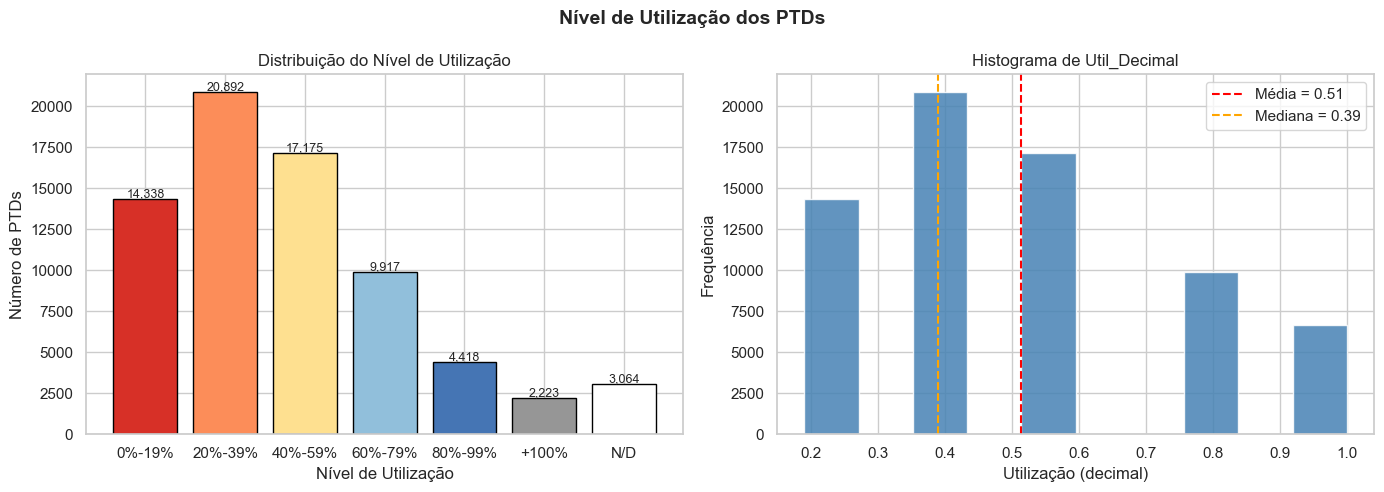

PTDs com utilização acima de 80%: 6,641 (9.6%)


In [7]:
util_col = [c for c in df.columns if 'Utiliza' in c][0]
util_counts = df[util_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras por categoria
cores = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4', '#969696', '#ffffff']
cats_order = ['0%-19%', '20%-39%', '40%-59%', '60%-79%', '80%-99%', '+100%', 'N/D']
ordered = [util_counts.get(c, 0) for c in cats_order]
axes[0].bar(cats_order, ordered, color=cores[:len(cats_order)], edgecolor='black')
axes[0].set_xlabel('Nível de Utilização')
axes[0].set_ylabel('Número de PTDs')
axes[0].set_title('Distribuição do Nível de Utilização')
for i, v in enumerate(ordered):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Histograma de Util_Decimal (excluindo N/D)
util_dec = df['Util_Decimal'].dropna()
axes[1].hist(util_dec, bins=10, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(util_dec.mean(), color='red', linestyle='--', label=f'Média = {util_dec.mean():.2f}')
axes[1].axvline(util_dec.median(), color='orange', linestyle='--', label=f'Mediana = {util_dec.median():.2f}')
axes[1].set_xlabel('Utilização (decimal)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Histograma de Util_Decimal')
axes[1].legend()

plt.suptitle('Nível de Utilização dos PTDs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PTDs com utilização acima de 80%: {(util_dec >= 0.8).sum():,} ({(util_dec >= 0.8).mean()*100:.1f}%)')

### 2.4 Distribuição das Variáveis Numéricas Principais

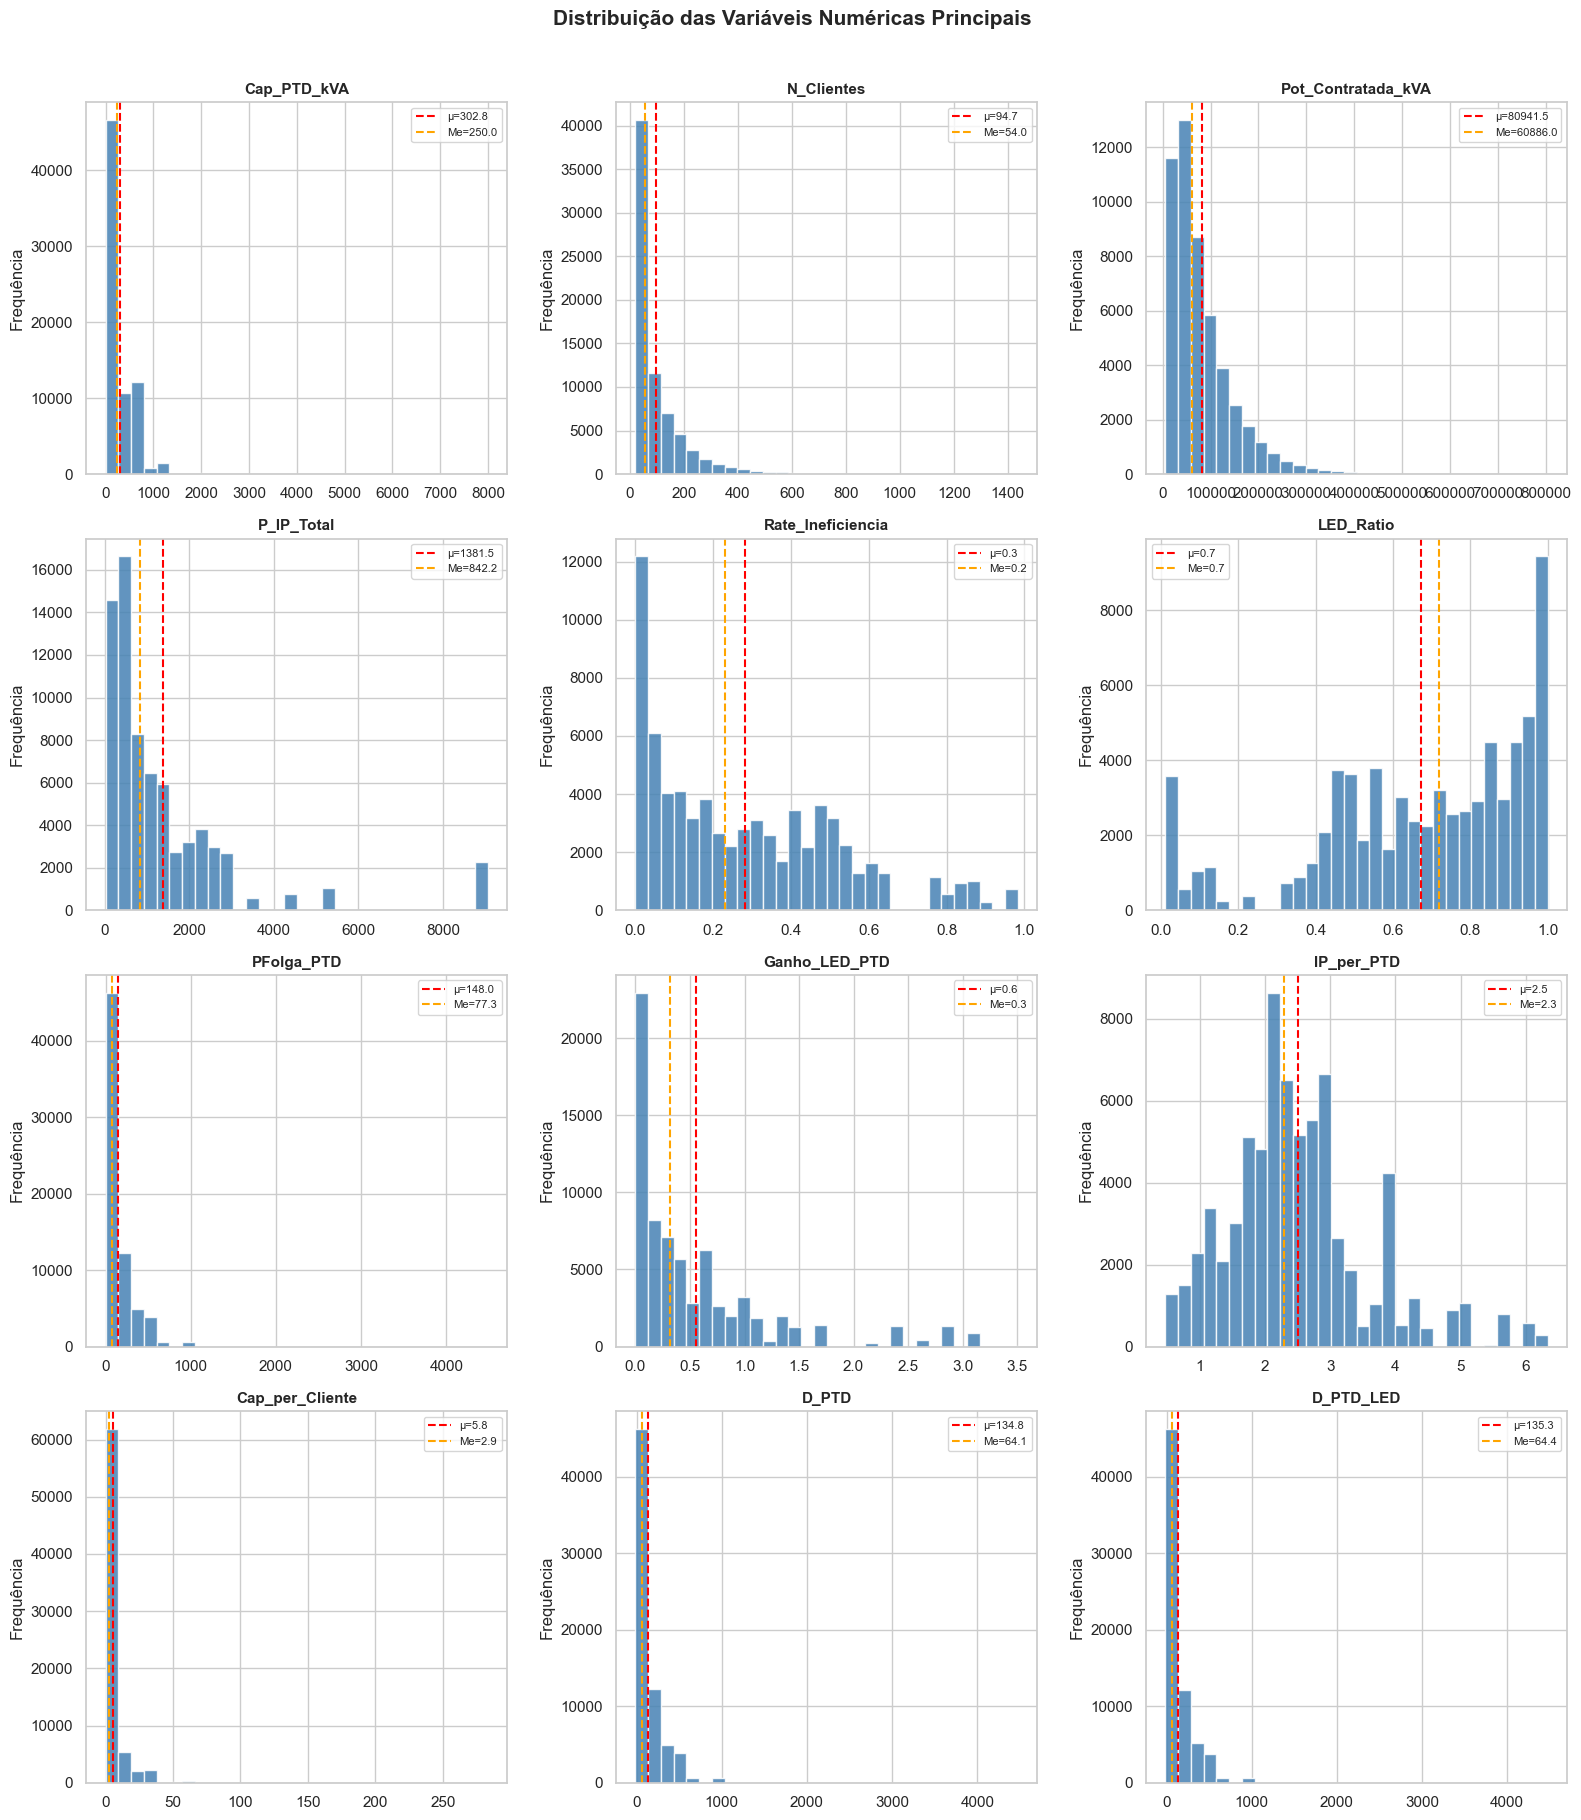

Assimetria (skewness) das variáveis principais:
Cap_per_Cliente       6.00
PFolga_PTD            3.77
D_PTD                 3.77
D_PTD_LED             3.76
Cap_PTD_kVA           3.41
P_IP_Total            3.00
N_Clientes            2.88
Pot_Contratada_kVA    2.14
Ganho_LED_PTD         1.97
IP_per_PTD            0.93
Rate_Ineficiencia     0.77
LED_Ratio            -0.83


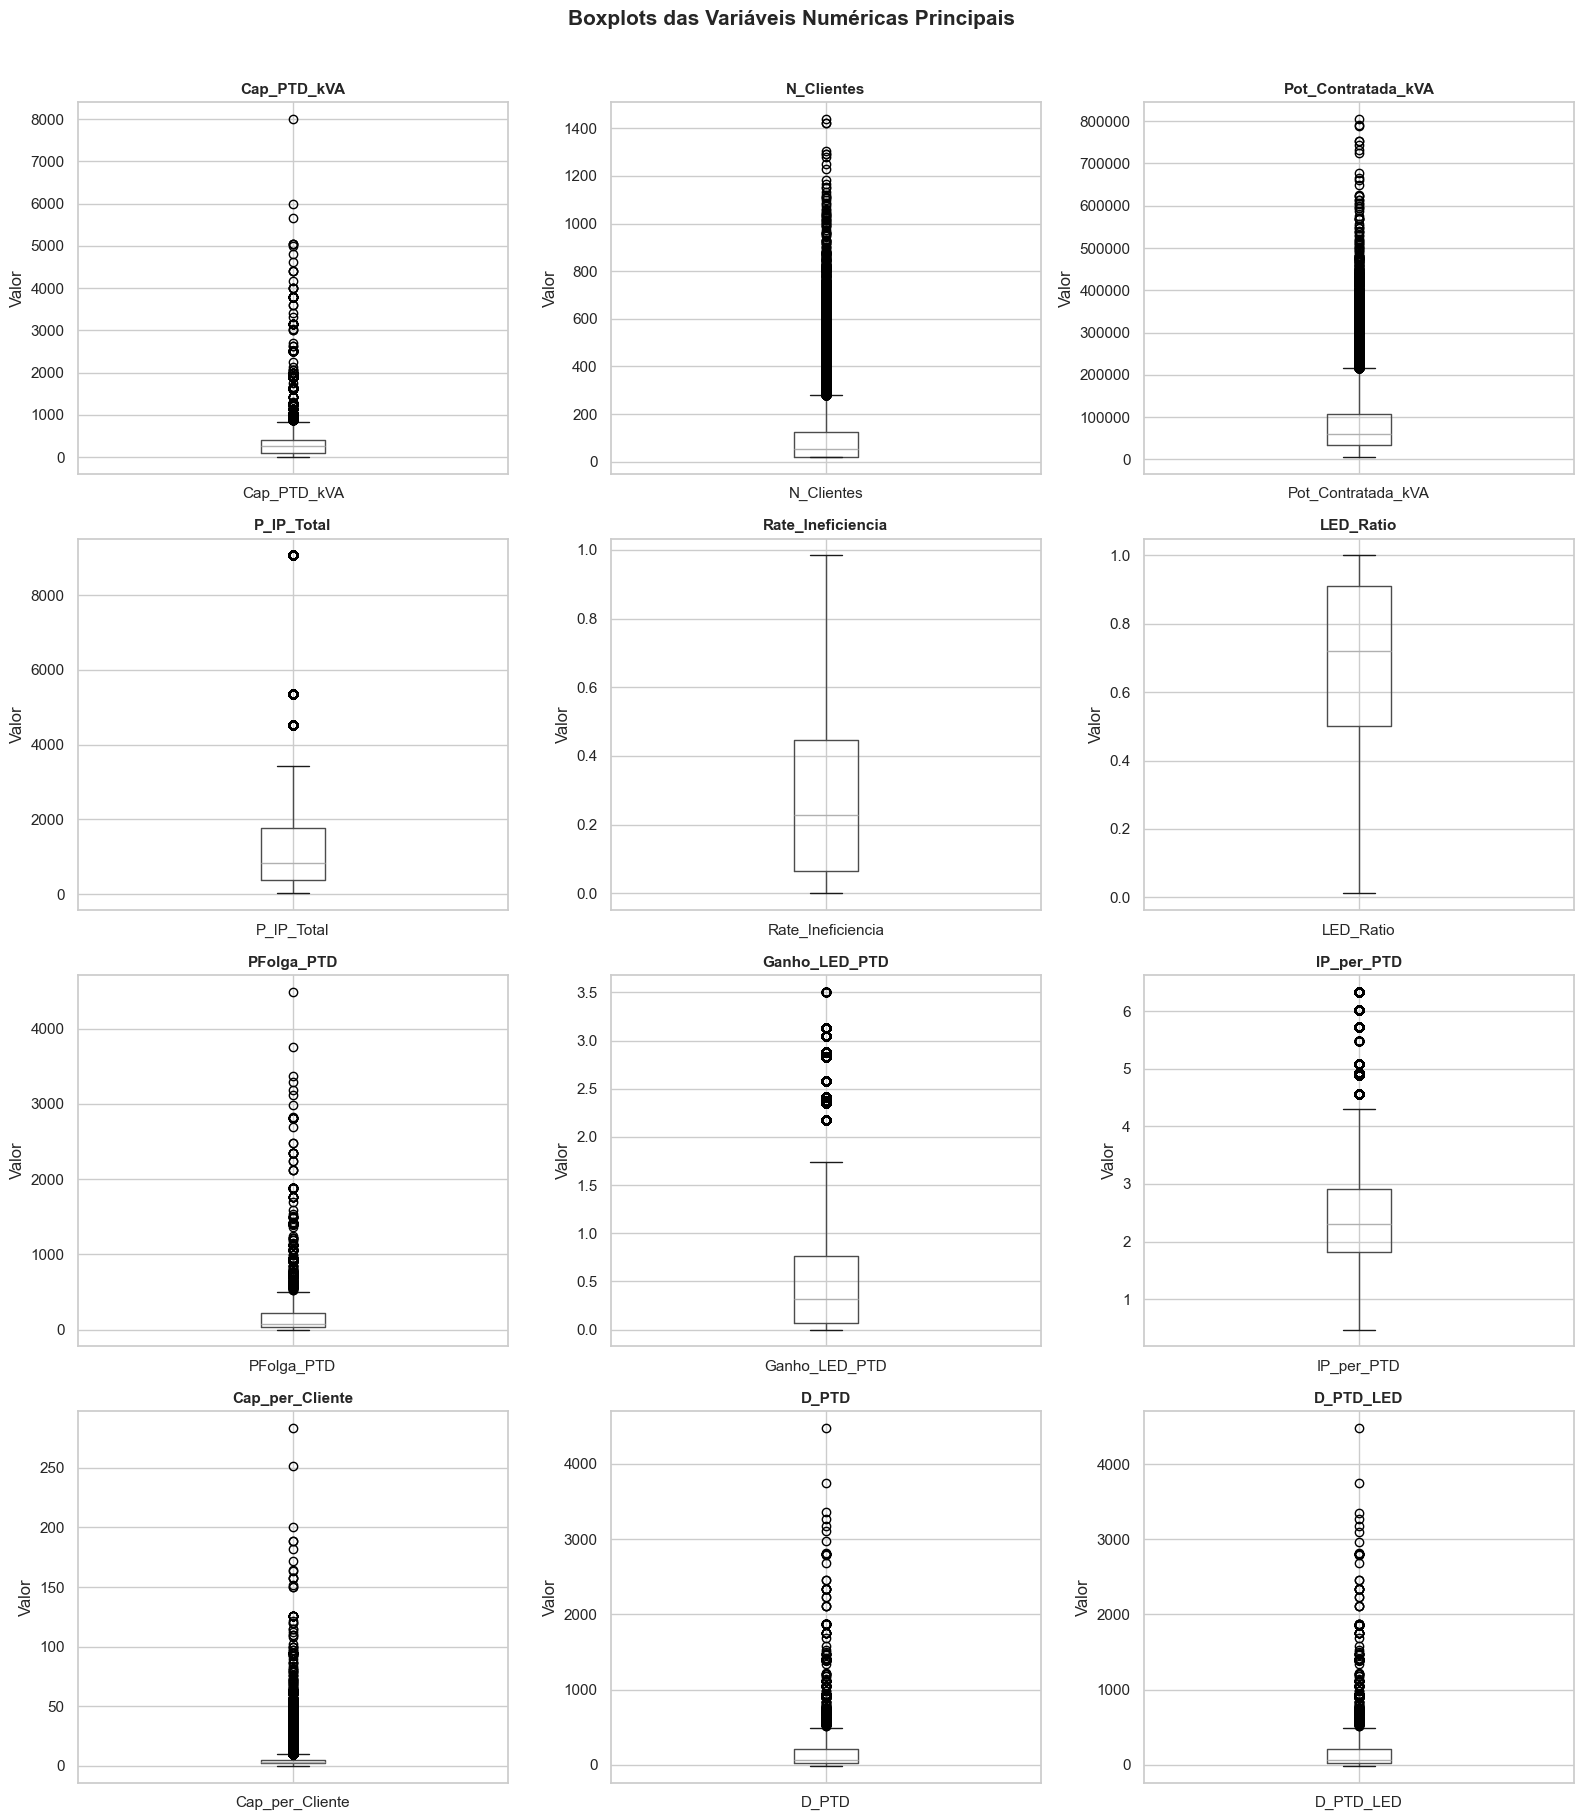

In [8]:
vars_principais = [
    'Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA',
    'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio',
    'PFolga_PTD', 'Ganho_LED_PTD', 'IP_per_PTD',
    'Cap_per_Cliente', 'D_PTD', 'D_PTD_LED'
]

# ── Histogramas ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(vars_principais):
    data = df[col].dropna()
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'μ={data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Me={data.median():.1f}')
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição das Variáveis Numéricas Principais', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Assimetria (skewness) ─────────────────────────────────────────────────────
print('Assimetria (skewness) das variáveis principais:')
skewness = df[vars_principais].skew().sort_values(ascending=False).round(2)
print(skewness.to_string())

# ── Boxplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(vars_principais):
    data = df[[col]].dropna()
    data.boxplot(ax=axes[i])
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots das Variáveis Numéricas Principais', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.5 Boxplots por Tipo Construtivo

C:\Users\zeraf\AppData\Local\Temp\ipykernel_10560\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zeraf\AppData\Local\Temp\ipykernel_10560\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zeraf\AppData\Local\Temp\ipykernel_10560\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zeraf\AppData\Local\Temp\ipykernel_10560\478343640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

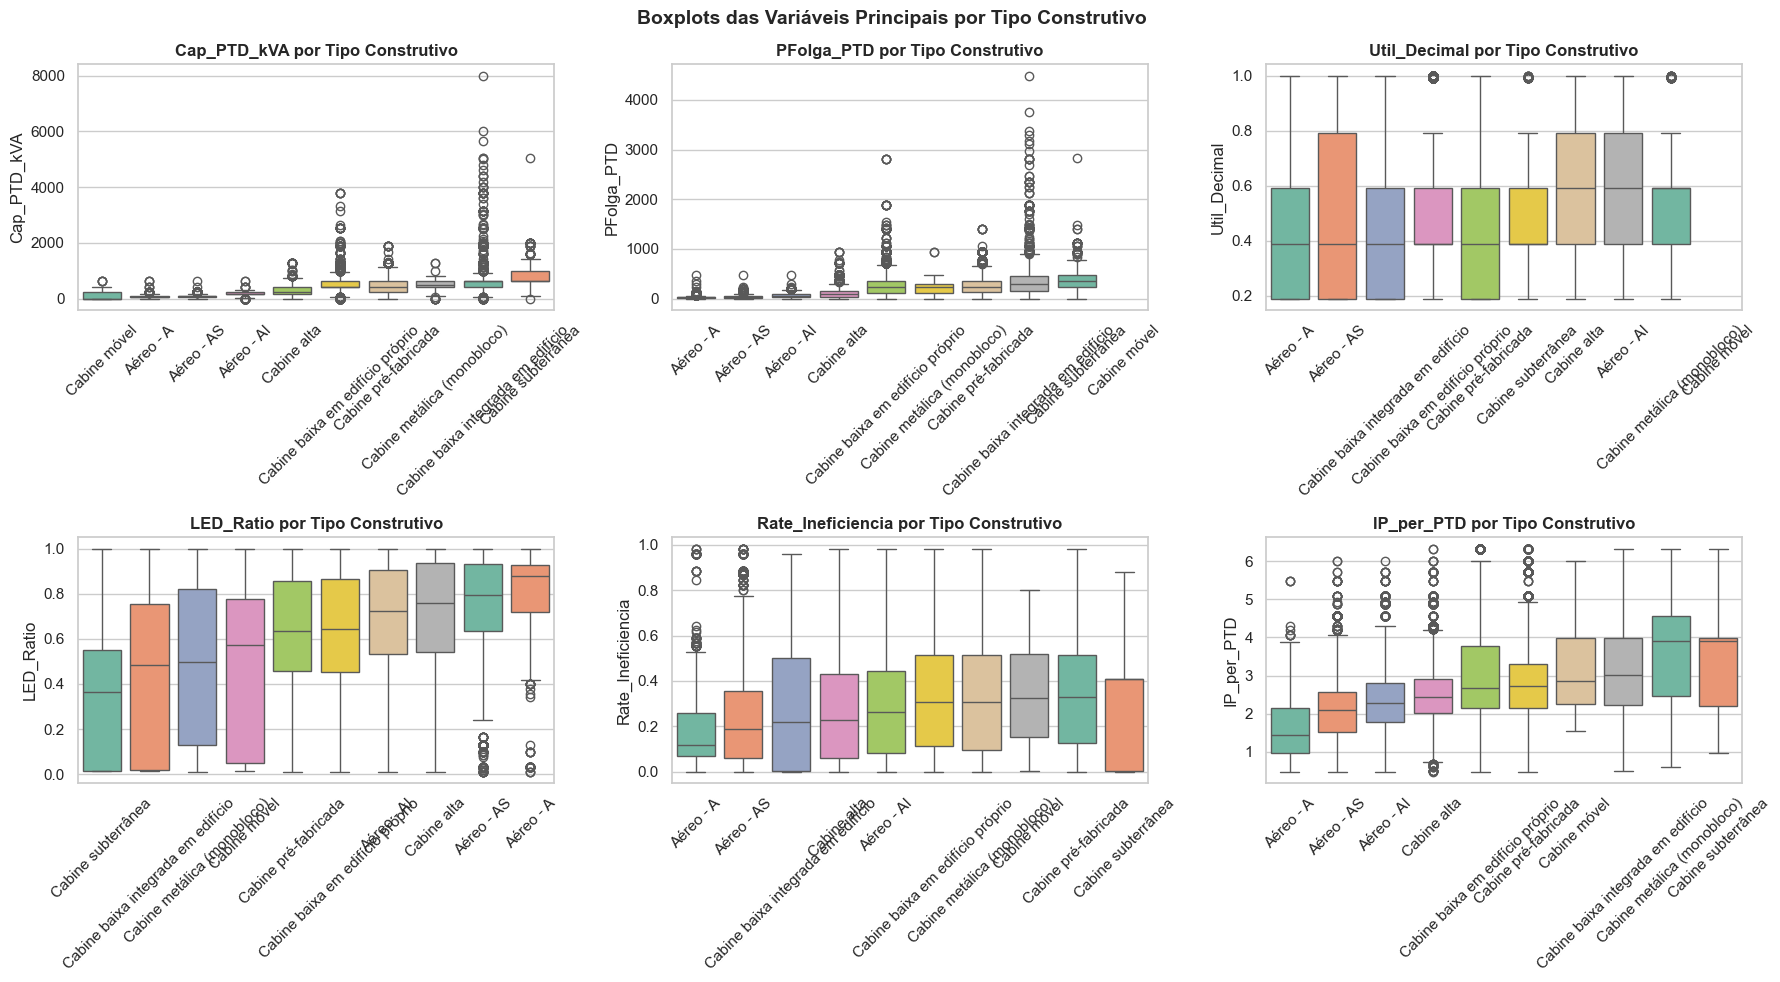

In [ ]:
vars_boxplot = ['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal',
                'N_Clientes', 'Cap_per_Cliente', 'D_PTD']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(vars_boxplot):
    order = df.groupby('Tipo Construtivo')[col].median().sort_values().index
    sns.boxplot(
        data=df, x='Tipo Construtivo', y=col,
        ax=axes[i], palette='Set2',
        hue='Tipo Construtivo', legend=False,
        order=order
    )
    axes[i].set_title(f'{col} por Tipo Construtivo', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Boxplots das Variáveis Principais por Tipo Construtivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Matriz de Correlação

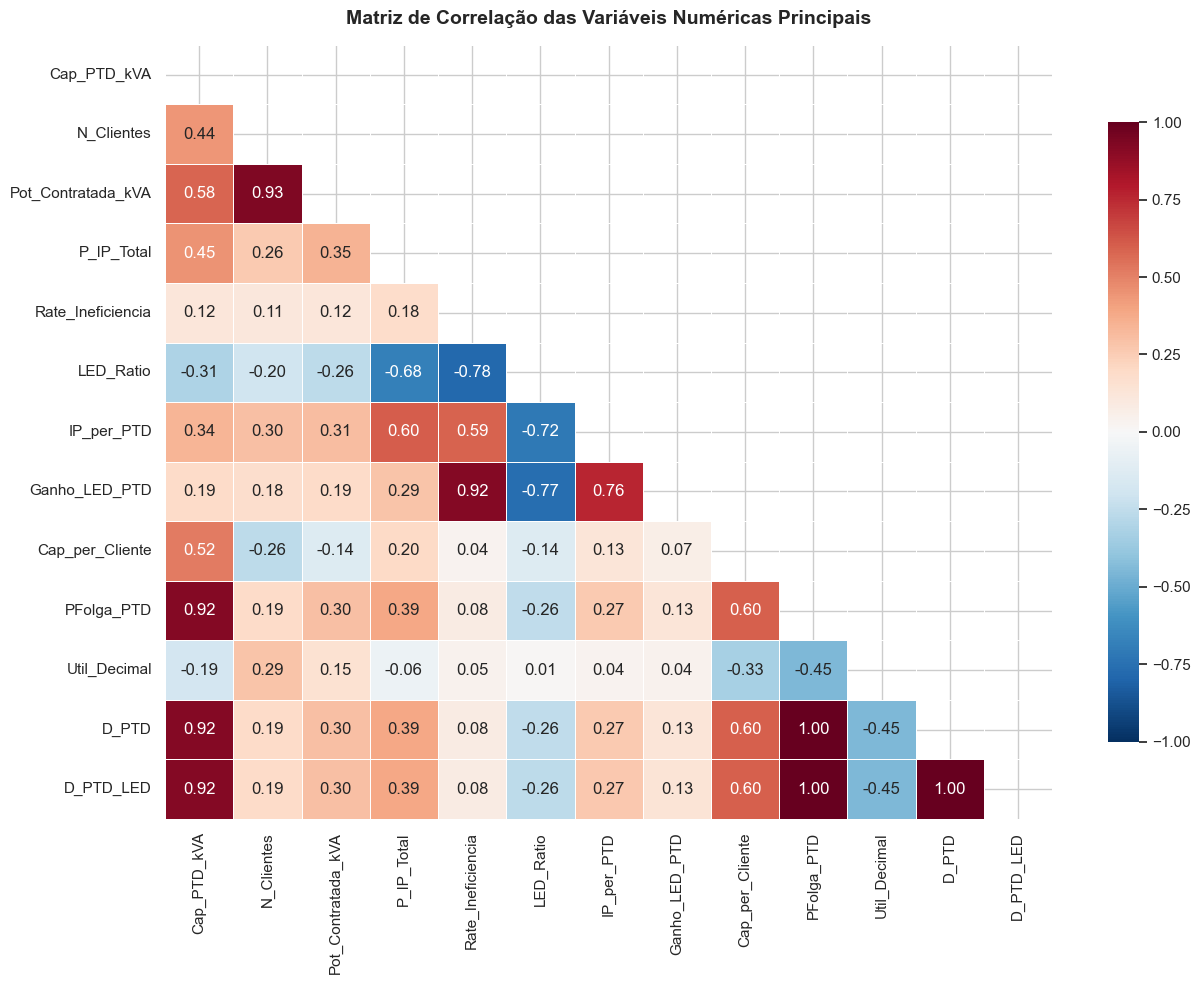

In [10]:
vars_corr = [
    'Cap_PTD_kVA', 'N_Clientes', 'Pot_Contratada_kVA',
    'P_IP_Total', 'Rate_Ineficiencia', 'LED_Ratio',
    'IP_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente',
    'PFolga_PTD', 'Util_Decimal', 'D_PTD', 'D_PTD_LED'
]

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de Correlação das Variáveis Numéricas Principais', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 2.7 Relações-Chave entre Variáveis

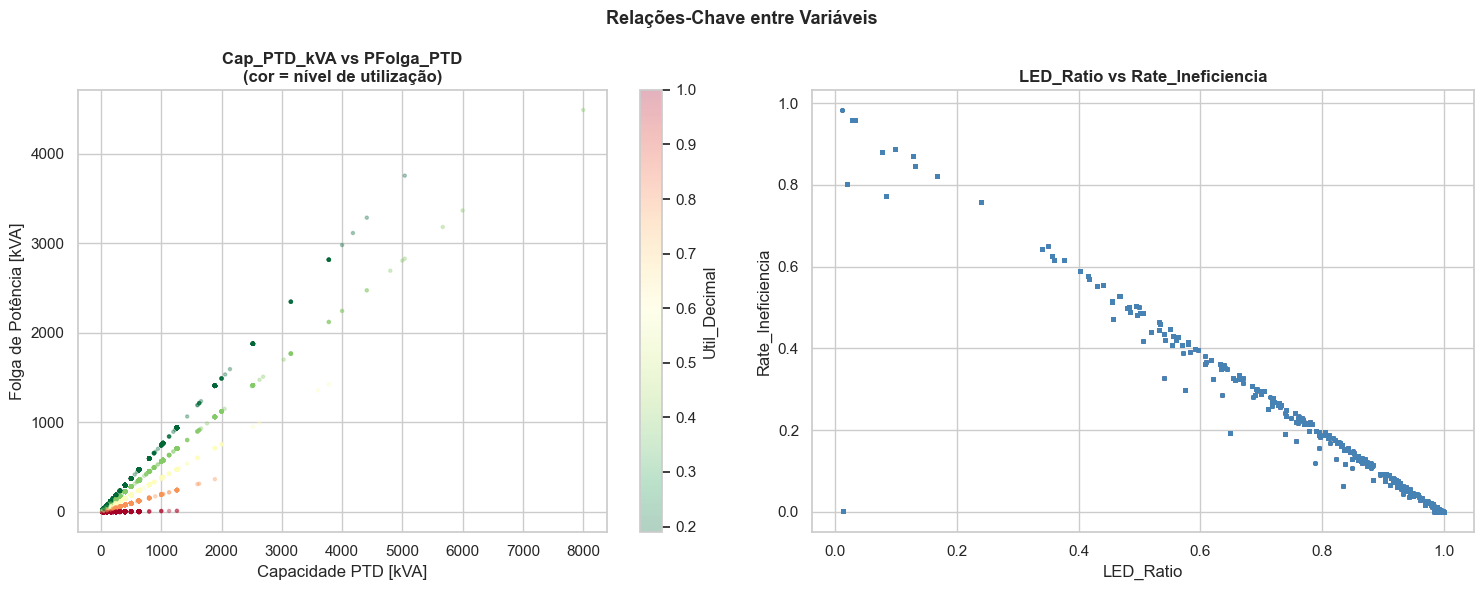

In [11]:
# Folga de Potência vs Capacidade do PTD — colorido por Tipo Construtivo
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter_data = df[['Cap_PTD_kVA', 'PFolga_PTD', 'Util_Decimal', 'LED_Ratio',
                    'Rate_Ineficiencia', 'Tipo Construtivo']].dropna()

# Scatter: Cap_PTD_kVA vs PFolga_PTD
sc1 = axes[0].scatter(
    scatter_data['Cap_PTD_kVA'], scatter_data['PFolga_PTD'],
    c=scatter_data['Util_Decimal'], cmap='RdYlGn_r',
    alpha=0.3, s=5
)
plt.colorbar(sc1, ax=axes[0], label='Util_Decimal')
axes[0].set_xlabel('Capacidade PTD [kVA]')
axes[0].set_ylabel('Folga de Potência [kVA]')
axes[0].set_title('Cap_PTD_kVA vs PFolga_PTD\n(cor = nível de utilização)', fontweight='bold')

# Scatter: LED_Ratio vs Rate_Ineficiencia
sc2 = axes[1].scatter(
    scatter_data['LED_Ratio'], scatter_data['Rate_Ineficiencia'],
    alpha=0.2, s=5, color='steelblue'
)
axes[1].set_xlabel('LED_Ratio')
axes[1].set_ylabel('Rate_Ineficiencia')
axes[1].set_title('LED_Ratio vs Rate_Ineficiencia', fontweight='bold')

plt.suptitle('Relações-Chave entre Variáveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

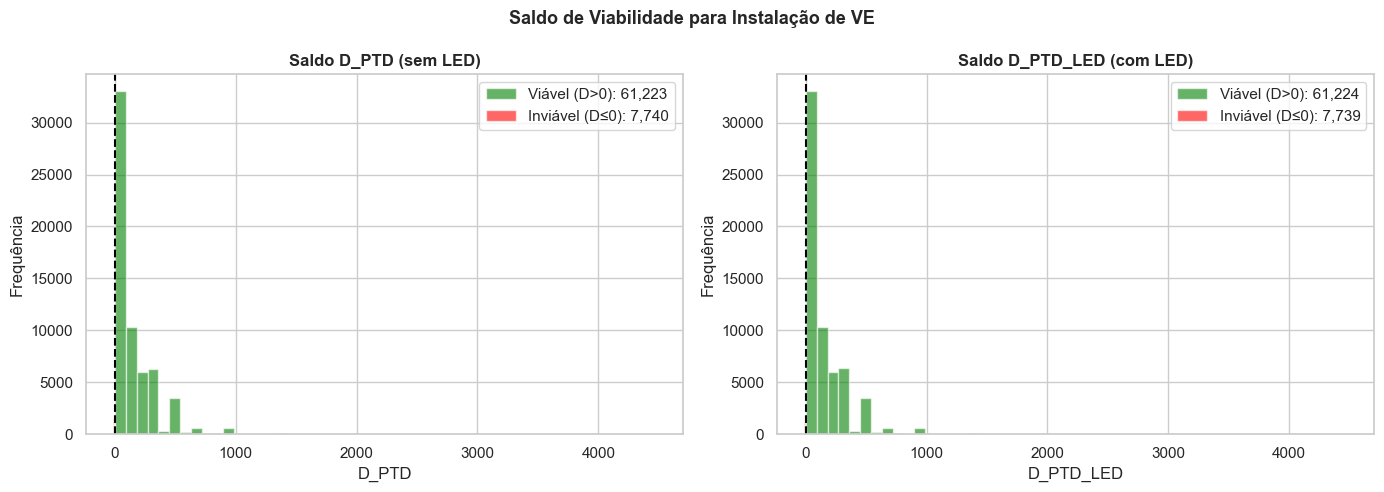

PTDs viáveis SEM LED:  61,223 / 68,963 (88.8%)
PTDs viáveis COM LED:  61,224 / 68,963 (88.8%)


In [12]:
# Distribuição de D_PTD e D_PTD_LED — Viabilidade de VE
d_data = df[['D_PTD', 'D_PTD_LED']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['D_PTD', 'D_PTD_LED'],
                           ['Saldo D_PTD (sem LED)', 'Saldo D_PTD_LED (com LED)']):
    data = d_data[col]
    pos = (data > 0).sum()
    neg = (data <= 0).sum()
    ax.hist(data[data > 0], bins=50, color='green', alpha=0.6, label=f'Viável (D>0): {pos:,}')
    ax.hist(data[data <= 0], bins=30, color='red', alpha=0.6, label=f'Inviável (D≤0): {neg:,}')
    ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.suptitle('Saldo de Viabilidade para Instalação de VE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

total = len(d_data)
print(f'PTDs viáveis SEM LED:  {(d_data["D_PTD"] > 0).sum():,} / {total:,} ({(d_data["D_PTD"] > 0).mean()*100:.1f}%)')
print(f'PTDs viáveis COM LED:  {(d_data["D_PTD_LED"] > 0).sum():,} / {total:,} ({(d_data["D_PTD_LED"] > 0).mean()*100:.1f}%)')

---
## 3. Pré-processamento dos Dados
### 3.1 Tratamento de Valores Omissos

In [13]:
df_clean = df.copy()

# Pot_Geracao_kW e Geracao_per_Cliente: ~97% de valores omissos → remover colunas
cols_drop_missing = ['Pot_Geracao_kW', 'Geracao_per_Cliente']
df_clean.drop(columns=cols_drop_missing, inplace=True)
print(f'Colunas removidas por excesso de valores omissos (>95%): {cols_drop_missing}')

# Nível de Utilização com valor "N/D" corresponde às mesmas linhas com PFolga_PTD = NaN
# Remover registos sem PFolga_PTD (não é possível calcular métricas principais)
n_antes = len(df_clean)
util_col = [c for c in df_clean.columns if 'Utiliza' in c][0]
df_clean = df_clean[df_clean[util_col] != 'N/D'].copy()
df_clean.dropna(subset=['PFolga_PTD', 'D_PTD', 'Util_Decimal'], inplace=True)
print(f'Registos removidos (PFolga_PTD/Util indefinido): {n_antes - len(df_clean):,}')
print(f'Registos restantes: {len(df_clean):,}')

# Pot_Contratada_kVA: ~29% de valores omissos → imputar com mediana por Tipo Construtivo
df_clean['Pot_Contratada_kVA'] = df_clean.groupby('Tipo Construtivo')['Pot_Contratada_kVA'].transform(
    lambda x: x.fillna(x.median())
)
df_clean['PContratada_per_Cliente'] = df_clean.groupby('Tipo Construtivo')['PContratada_per_Cliente'].transform(
    lambda x: x.fillna(x.median())
)
print(f'\nValores omissos restantes:')
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Colunas removidas por excesso de valores omissos (>95%): ['Pot_Geracao_kW', 'Geracao_per_Cliente']
Registos removidos (PFolga_PTD/Util indefinido): 3,064
Registos restantes: 68,963

Valores omissos restantes:
Series([], dtype: int64)


### 3.2 Transformação de Variáveis Categóricas

In [ ]:

# Tipo Construtivo → One-Hot Encoding (todas as categorias, sem agrupamento)
print('Categorias de Tipo Construtivo:')
print(df_clean['Tipo Construtivo'].value_counts().to_string())

df_clean = pd.get_dummies(df_clean, columns=['Tipo Construtivo'], drop_first=False, dtype=int)
cols_ohe_tipo = [c for c in df_clean.columns if 'Tipo Construtivo' in c]
print(f'\nColunas OHE Tipo Construtivo ({len(cols_ohe_tipo)}): {cols_ohe_tipo}')

# Distrito → One-Hot Encoding
print(f'\nDistritos únicos: {df_clean["Distrito"].nunique()}')
print(df_clean['Distrito'].value_counts().to_string())

df_clean = pd.get_dummies(df_clean, columns=['Distrito'], drop_first=False, dtype=int)
cols_ohe_dist = [c for c in df_clean.columns if c.startswith('Distrito_')]
print(f'\nColunas OHE Distrito ({len(cols_ohe_dist)}): {cols_ohe_dist}')


### 3.3 Seleção de Variáveis Relevantes

In [ ]:

# Variáveis removidas e justificação:
# [Identificadores]    : Concelho, Código de Instalação, Coordenadas Geográficas, CodDistritoConcelho
# [Data leakage]       : D_PTD, D_PTD_LED  (derivadas diretas de PFolga_PTD)
# [Constante]          : PVE_PTD  (único valor = 13,2 kW)
# [Duplicado]          : Potência instalada [kVA]  (== Cap_PTD_kVA, corr = 1,0)
# [97% omissos]        : Pot_Geracao_kW, Geracao_per_Cliente  (removidas na secção 3.1)
# [Redundante]         : Nível de Utilização [%]  (substituída por Util_Decimal)
# [Multicolinearidade] : N_Lampadas  (== N_Luminarias), IP_Inef_per_PTD  (== IP_per_PTD × Rate_Ineficiencia)

pot_col      = [c for c in df_clean.columns if 'instalada' in c][0]
util_col_str = [c for c in df_clean.columns if 'Utiliza' in c][0]
cod_col      = [c for c in df_clean.columns if 'digo' in c][0]
coord_col    = [c for c in df_clean.columns if 'Coordenadas' in c][0]

cols_remover = [
    'Concelho', 'CodDistritoConcelho', cod_col, coord_col,  # identificadores
    'D_PTD', 'D_PTD_LED',                                   # data leakage
    'PVE_PTD',                                              # constante
    pot_col,                                                # duplicado
    util_col_str,                                           # redundante
    'N_Lampadas', 'IP_Inef_per_PTD',                        # multicolinearidade
]

cols_remover_existentes = [c for c in cols_remover if c in df_clean.columns]
df_model = df_clean.drop(columns=cols_remover_existentes)

print(f'Variáveis removidas nesta etapa ({len(cols_remover_existentes)}):')
for c in cols_remover_existentes:
    print(f'  ✗ {c}')

print(f'\nTotal de variáveis finais: {df_model.shape[1]}')
print(f'\nVariáveis selecionadas para modelação:')
for c in df_model.columns:
    print(f'  {c:<55} dtype={df_model[c].dtype}')


### 3.4 Normalização / Standardização

In [ ]:

# Colunas OHE (binárias) — não normalizar
cols_ohe = [c for c in df_model.columns if 'Tipo Construtivo' in c or c.startswith('Distrito_')]

cols_numericas = [c for c in df_model.select_dtypes(include=np.number).columns
                  if c not in cols_ohe]

scaler = StandardScaler()
df_scaled = df_model.copy()
df_scaled[cols_numericas] = scaler.fit_transform(df_model[cols_numericas])

print(f'Variáveis NÃO normalizadas (OHE binárias — {len(cols_ohe)}):')
print(cols_ohe)

print(f'\nVariáveis normalizadas com StandardScaler ({len(cols_numericas)}):')
print(cols_numericas)

print(f'\nEstatísticas após normalização (devem ter μ≈0, σ≈1):')
print(df_scaled[cols_numericas].describe().loc[['mean', 'std']].round(4).T)

print('\nNota: o scaler foi ajustado em todo o dataset (para EDA).')
print('Na modelação, o fit será feito apenas nos dados de treino.')


---
## 4. Sumário Final do Dataset Pré-processado

In [ ]:

SEP  = '=' * 55
SEP2 = '-' * 55

cols_ohe_tipo = [c for c in df_model.columns if 'Tipo Construtivo' in c]
cols_ohe_dist = [c for c in df_model.columns if c.startswith('Distrito_')]
n_ohe_total   = len(cols_ohe_tipo) + len(cols_ohe_dist)
n_removidas   = 13  # 2 em 3.1 (omissos) + 11 em 3.3 (seleção)
n_adicionadas = n_ohe_total  # OHE substituiu 2 colunas por n_ohe_total

print(SEP)
print('       RESUMO DO PRÉ-PROCESSAMENTO')
print(SEP)
print(f'Dataset original:        {df.shape[0]:>7,} registos × {df.shape[1]:>2} variáveis')
print(f'Registos removidos:        3,064  (Nível de Utilização = N/D)')
print(f'Registos finais:         {df_model.shape[0]:>7,}')
print(SEP2)
print(f'Colunas removidas:       {n_removidas:>6}  (ver critérios abaixo)')
print(f'Colunas adicionadas:     {n_adicionadas:>6}  (one-hot encoding)')
print(f'Variáveis finais:        {df_model.shape[1]:>6}')
print(f'Valores omissos rem.:    {df_model.isnull().sum().sum():>6}')
print(SEP)

print('\nCritérios de remoção (13 colunas):')
print('  [Identificadores]      : Concelho, Código de Instalação,')
print('                           Coordenadas Geográficas,')
print('                           CodDistritoConcelho')
print('  [Data leakage]         : D_PTD, D_PTD_LED')
print('  [Constante]            : PVE_PTD')
print('  [Duplicado]            : Potência instalada [kVA]')
print('  [97% omissos]          : Pot_Geracao_kW, Geracao_per_Cliente')
print('  [Redundante]           : Nível de Utilização [%]')
print('  [Multicolinearidade]   : N_Lampadas, IP_Inef_per_PTD')

print(f'\nOne-hot encoding (2 → {n_ohe_total} colunas):')
print(f'  Tipo Construtivo ({len(cols_ohe_tipo)} categorias)')
tc_nomes = [c.replace('Tipo Construtivo_', '') for c in cols_ohe_tipo]
print(f'    {", ".join(tc_nomes)}')
print(f'  Distrito         ({len(cols_ohe_dist)} distritos)')
dist_nomes = sorted([c.replace('Distrito_', '') for c in cols_ohe_dist])
print(f'    {", ".join(dist_nomes)}')

# ── Variáveis finais agrupadas ──────────────────────────────────────────────
print(f'\n{SEP}')
print(f'Variáveis finais ({df_model.shape[1]}):')

ptd_cols  = ['Cap_PTD_kVA', 'Pot_Contratada_kVA', 'N_Clientes', 'N_Clientes_Produtores']
ip_cols   = ['P_IP_Total', 'P_IP_Inef', 'Rate_Ineficiencia', 'LED_Ratio', 'N_Luminarias', 'N_PTDs_Concelho']
der_cols  = ['IP_per_PTD', 'Ganho_LED_PTD', 'Cap_per_Cliente', 'PContratada_per_Cliente', 'Clientes_Produtores_Ratio']
alvo_cols = ['PFolga_PTD', 'Util_Decimal']

def fmt_lista(cols, width=60):
    line, lines = '', []
    for c in cols:
        if len(line) + len(c) + 2 > width:
            lines.append(line.rstrip(', '))
            line = ''
        line += c + ', '
    if line:
        lines.append(line.rstrip(', '))
    return lines

def print_grupo(titulo, cols):
    existentes = [c for c in cols if c in df_model.columns]
    print(f'\n  [{titulo} ({len(existentes)})]:', )
    for l in fmt_lista(existentes):
        print(f'    {l}')

print_grupo('Nível do PTD', ptd_cols)
print_grupo('Iluminação Pública — concelho', ip_cols)
print_grupo('Variáveis derivadas', der_cols)

print(f'\n  [Alvos (2)]:')
print(f'    PFolga_PTD   (regressão)')
print(f'    Util_Decimal (base da classificação)')

print(f'\n  [Tipo Construtivo — dummies ({len(cols_ohe_tipo)})]:', )
for l in fmt_lista(tc_nomes):
    print(f'    {l}')

print(f'\n  [Distrito — dummies ({len(cols_ohe_dist)})]:', )
for l in fmt_lista(dist_nomes):
    print(f'    {l}')

print(f'\n{SEP}')
print(f'  df_model  (sem normalização) : {df_model.shape}')
print(f'  df_scaled (StandardScaler)   : {df_scaled.shape}')
print(SEP)


In [ ]:

# Visualização final: distribuição das variáveis numéricas após standardização
cols_ohe = [c for c in df_model.columns if 'Tipo Construtivo' in c or c.startswith('Distrito_')]
cols_numericas = [c for c in df_model.select_dtypes(include=np.number).columns if c not in cols_ohe]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols_numericas[:12]):
    sns.kdeplot(df_scaled[col].dropna(), ax=axes[i], fill=True, color='steelblue', alpha=0.6)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Valor padronizado (z-score)')
    axes[i].set_ylabel('')

for j in range(min(len(cols_numericas), 12), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Densidade das Variáveis Após Standardização (z-score)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
